**1- Importing the Required Libraries**

We import the libraries needed for data analysis, machine learning, visualization, and statistical plotting: Pandas, NumPy, Scikit-learn, Matplotlib, and Seaborn.

In [1]:
import sys
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
pd.set_option('display.float_format', lambda x: '%.2f' % x)


In [2]:
from sklearn.model_selection import train_test_split 

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:

sys.path.append(os.path.abspath('..'))

from config.path import DATA_RAW_PATH, DATA_PROCESSED_PATH, PRE_TRAINED_MODEL_RESULTS_PATH ,HYPERPARAMETER_OPTIMIZATION_RESULTS_PATH

In [4]:
df = pd.read_csv(DATA_PROCESSED_PATH)
df.head()


,year,selling_price,km_driven,owner,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,fuel_nan,transmission_Automatic,transmission_Manual,transmission_nan,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,seller_type_nan,brand
0,2007.00,60000,70000.00,1,False,False,False,False,True,False,False,True,False,False,True,False,False,18
1,2007.00,135000,50000.00,0,False,False,False,False,True,False,False,True,False,False,True,False,False,18
2,2012.00,600000,100000.00,1,False,True,False,False,False,False,False,True,False,False,True,False,False,10
3,2017.00,250000,46000.00,1,False,False,False,False,True,False,False,True,False,False,True,False,False,5
4,2014.00,450000,141000.00,2,False,True,False,False,False,False,False,True,False,False,True,False,False,9


In [5]:
X = df.drop(columns=['selling_price'])
Y = df['selling_price']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 2696 samples
Test set size: 674 samples


In [6]:
models = {
    'Linear Regression' : Pipeline([
        ('scaler' , StandardScaler()), 
        ('model' , LinearRegression())
    ]), 
    'Random Forest' : Pipeline([
        ('scaler' , StandardScaler()),
        ('model' , RandomForestRegressor(random_state=42))
    ]) , 
    'XGBoost' : Pipeline([
        ('scaler' , StandardScaler()),
        ('model' , XGBRegressor(random_state=42))
    ]),
    'Support Vector Regression' : Pipeline([
        ('scaler' , StandardScaler()) , 
        ('model', SVR())
    ])
}


In [12]:
results = []

for name, pipline in models.items() : 
    pipline.fit(X_train, Y_train) 

    Y_pred = pipline.predict(X_test)

    mse = mean_squared_error(Y_test, Y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(Y_test, Y_pred)
    r2 = r2_score(Y_test, Y_pred)

    results.append({
        'Model' : name,
        'MSE' : mse,
        'RMSE' : rmse,
        'MAE' : mae,
        'R2' : r2
    })

results_df = pd.DataFrame(results).sort_values(by='R2' , ascending=False).reset_index(drop=True)


results_df.to_csv(PRE_TRAINED_MODEL_RESULTS_PATH, index=False)


KeyboardInterrupt: 

In [8]:
df_baseline = pd.read_csv(PRE_TRAINED_MODEL_RESULTS_PATH)
df_hyperparameter = pd.read_csv(HYPERPARAMETER_OPTIMIZATION_RESULTS_PATH)

In [9]:
df_comparison = pd.concat([df_baseline, df_hyperparameter], axis=0, ignore_index=True )

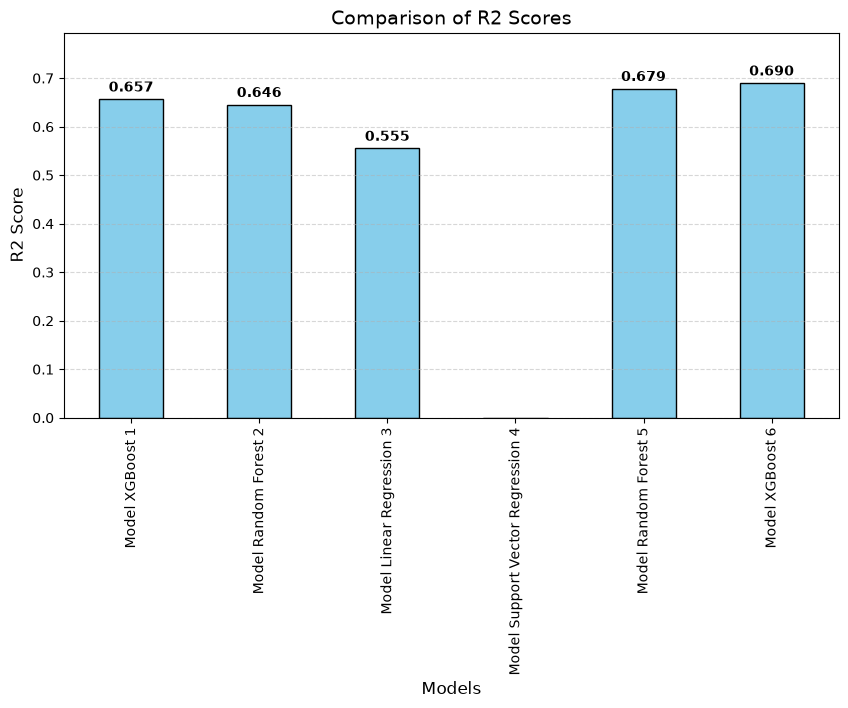

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

x_labels = [f"Model {df_comparison.iloc[i]['Model']} {i+1}" for i in range(len(df_comparison))]
y_values = df_comparison['R2']

bars = plt.bar(x_labels, y_values, color='skyblue', edgecolor='black', width=0.5)

plt.bar_label(bars, fmt='%.3f', padding=3, fontsize=10, weight='bold')

plt.title('Comparison of R2 Scores', fontsize=14)
plt.xlabel('Models', fontsize=12)
plt.ylabel('R2 Score', fontsize=12)

plt.xticks(rotation=90)


plt.ylim(0, max(y_values) * 1.15)  
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()